This is code that explores environmental dependencies, comparing random environmental noise (realized in birth rates) to trait matching functions. The latter represents a scenario in which species may be better or more poorly adapted to environments their populations are  found in. (**FOR NOW: all birth rates remain positive, as all species are modeled akin to logistically-growing producers**)
1. Random noise. Each subsampling trial will be accompanied by a random perturbation of each subsampled species' intrinsic birth rate. 
2. Trait matching. Assume an environment along a gradient with a trait optimum between 0 to 1. Each species is assigned a trait value (independent of their interactions with other species). The degree to which a particular species' trait matches the environment for a particular subsampling trial will perturb its intrinsic birth rate; high mismatch will lead to low birth rates, and high matching will bolster it. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from importlib import reload
import networkx as nx
from sklearn import metrics
from scipy import stats
from scipy.stats import rankdata

import metaCommunityMx
import community_sim
import cluster_funcs
import metrics_and_plotting
import run_cooccurrence
reload(metaCommunityMx)
reload(community_sim)
reload(cluster_funcs)
reload(metrics_and_plotting)
reload(run_cooccurrence)

<module 'run_cooccurrence' from '/Users/fionacallahan/Documents/Nielsen_lab/TheoryCoOccur/run_cooccurrence.py'>

In [ ]:
# random env noise
# for random matrix
interactStren = 0.01
nSpec = 10
pPositive = 0.3
pInteract = 0.4 # this is only used for random matrix

# parms for GLV sim
alpha = 0.05 
samplesize = int(0.5 * nSpec) # number of species to sample
numtrials = 500
tmax = 50
#This generates a random list of birthrates between 0.9 and 1
b = np.ones(nSpec) - np.random.uniform(low = 0, high = 0.1, size = (nSpec))
randMx = metaCommunityMx.getRandomMatrix(maxInteractionStrength = interactStren, pPositive = pPositive, pInteract = pInteract, nSpecies = nSpec, pBidirectional = 0)

sim_res = community_sim.simulate_coOccurrence_randenv(samplesize = samplesize, numtrials = numtrials, a = randMx, b = b, alpha = alpha, tmax = tmax, y0 = None, noise = 0.5)
coAbd = np.round(sim_res[0], 0)
pearson_corr = np.corrcoef(coAbd, rowvar = False)
#print(pearson_corr)
#cutoff is hard set rn
network_coocc = np.greater(pearson_corr, 0.1).astype(int) - np.less(pearson_corr, -0.1).astype(int)
#print(network_coocc)
np.fill_diagonal(network_coocc, 0)
G_coocc = nx.from_numpy_array(network_coocc)

totalCoocEdge = sum(sum(network_coocc != 0))
totalPosCoocEdge = sum(sum(network_coocc > 0))

totalInteractEdge = sum(sum(randMx != 0))
totalPosInteractEdge = sum(sum(randMx > 0))

pPosCoocL = totalPosCoocEdge / totalCoocEdge
pPosInteractL = totalPosInteractEdge / totalInteractEdge
print(pPosCoocL)
print(pPosInteractL)
#sol = community_sim.run_communityDynamics(a = randMx, b = b, alpha = alpha, tmax = 50, y0 = None)

#plt.plot(sol.t, sol.y[0], sol.t, sol.y[1], sol.t,sol.y[2], sol.t,sol.y[3],sol.t,sol.y[4])

#abds_end = sol.y[:, -1]
#abds_end_m1 = sol.y[:, -2]



[1.19187592 0.91826864 0.58375211 0.99366892 0.98770263]
[1.43576075 0.70083332 0.76030084 0.48063299 0.80135209]
[1.06311636 1.1976863  0.98424305 0.74793023 0.70891679]
[0.71318524 1.37086163 1.39581639 0.86123281 1.39606292]
[1.03838549 0.5951985  1.05001337 0.87113117 0.92263939]
[0.71990516 1.29056524 1.21215029 1.14597126 0.72365288]
[1.05973422 0.93265823 0.44292074 0.86665079 1.42179426]
[0.80906826 0.4718173  1.14968405 1.41646732 0.64043649]
[0.62265181 1.48336275 0.64213948 1.30443205 1.31370929]
[1.00674033 0.8452209  0.80414304 0.83142456 0.8492354 ]
[1.16496224 1.2746233  0.73843989 0.96289584 0.77710307]
[1.15922872 0.84811398 1.05019021 0.97362312 0.47244387]
[1.20312056 1.38233587 0.53519915 1.16672554 1.26239807]
[0.64756551 0.94127743 1.06524664 0.49133766 0.99699783]
[1.02289589 1.24769031 0.84687167 1.35148139 0.8536616 ]
[0.77485519 1.30119296 1.13631551 1.24202187 1.26832116]
[0.75488434 1.18576349 0.9073604  1.1311089  1.12073243]
[0.6665978  0.60098181 0.728428

In [ ]:
#traitmatch function
#things to try out: birthrate noise due to env match, sampling biased part of env
# Parameters for all simulations
# for random matrix
interactStren = 0.01
nSpec = 100
pPositive = 0.3
pInteract = 0.4 # this is only used for random matrix

# parms for GLV sim
alpha = 0.05 
samplesize = int(0.5 * nSpec) # number of species to sample
numtrials = 500
tmax = 50

#generate random list of traits for each species between 0 and 1
traits = np.random.uniform(low = 0, high = 1, size = (nSpec))

#This generates a random list of birthrates between 0.9 and 1
b = np.ones(nSpec) - np.random.uniform(low = 0, high = 0.1, size = (nSpec))
randMx = metaCommunityMx.getRandomMatrix(maxInteractionStrength = interactStren, pPositive = pPositive, pInteract = pInteract, nSpecies = nSpec, pBidirectional = 0)

sim_res = community_sim.simulate_coOccurrence_traitmatch(samplesize = samplesize, numtrials = numtrials, a = randMx, b = b, alpha = alpha, traits = traits, tmax = tmax,  y0 = None, noise = 0.2)
coAbd = np.round(sim_res[0], 0)
pearson_corr = np.corrcoef(coAbd, rowvar = False)
#print(pearson_corr)
#cutoff is hard set rn!
network_coocc = np.greater(pearson_corr, 0.1).astype(int) - np.less(pearson_corr, -0.1).astype(int)
#print(network_coocc)
np.fill_diagonal(network_coocc, 0)
G_coocc = nx.from_numpy_array(network_coocc)

totalCoocEdge = sum(sum(network_coocc != 0))
totalPosCoocEdge = sum(sum(network_coocc > 0))

totalInteractEdge = sum(sum(randMx != 0))
totalPosInteractEdge = sum(sum(randMx > 0))

pPosCoocL = totalPosCoocEdge / totalCoocEdge
pPosInteractL = totalPosInteractEdge / totalInteractEdge
print(pPosCoocL)
print(pPosInteractL)

0.40855323020928114
0.2965159377316531


In [ ]:
# Trait Matching Environment Noise
traits = np.random.uniform(low = 0, high = 1, size = (nSpec))

pInteractL = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1] 
cutoffL = [0.05, 0.1, 0.15, 0.2]

totalCoocEdge_tm = np.zeros(shape = (len(pInteractL), len(cutoffL)))
totalInteractEdge_tm = np.zeros(shape = (len(pInteractL), len(cutoffL)))

for i in range(len(pInteractL)):
    pInteract = pInteractL[i]
    print(pInteract)
    for j in range(len(cutoffL)):
        cutoff = cutoffL[j]
        if pInteract in [0, 0.1, 0.2, 0.8, 1] and cutoff == 0.15:
            plotNet = True
        else:
            plotNet = False

        # make new interaction mx with different proportion of edges
        randMx = metaCommunityMx.getRandomMatrix(maxInteractionStrength = interactStren, pPositive = pPositive, pInteract = pInteract, nSpecies = nSpec, pBidirectional = 0)

        # run sim to get coocurrence network
        network_rand, G_rand_coocc = run_cooccurrence.get_coocc_network_traitmatch(interactionMx = randMx, cutoff = cutoff, alpha = alpha, spsamplesize = samplesize, numtrials = numtrials, b = b, traits = traits, plotNetworks = plotNet, noise = 0.6)
        G_rand_inter = nx.from_numpy_array(randMx != 0)

        # save stats
        totalCoocEdge_tm[i,j] = sum(sum(network_rand != 0))
        totalInteractEdge_tm[i,j] = sum(sum(randMx != 0))

    

In [ ]:
#TODO - I think most of this needs to be redone with a different means of implementing environmental noise. Right now higher noise fundamentally reduces the 
#average birth rate in the community, which biases influence towards interspecific interactions - very plausible that this is what is driving an 
#increased predictive power of changed interactions under environmental noise. 

#DONE - random network, random interactions, random environmental prefs. Trait matching env-style noise. Randomly select n interactions
#that are going to change in different environments. Run simulation in env 1 (0) and then env 2(1). Calculate delta(edge strength) in cooc, plot
#against delta(edge strength) in interaction network. Made ROC curves detecting change/did not change, filtered by within vs different environmental
#preferences. Ran these many times to plot a mean and confidence interval; within vs between env preference interactions are a wash when averaged out. 
#Also have verison where same interaction matrix is run with different amounts of environmental influence (noise = 0, 0.3, 0.6); not a consistent pattern
#in terms of which noise level leads to highest AUC. Is this driven by the predominance of non interactions? 


0
47
[63 26 75 38 10 60 41 86 86 57 38 91 33 53 86 48  3 97 76 36 83 96 13 30
 18 21 86 29 26 73 48 33 47 46 10 86 36 83 52 44  9 28 52 85 70 12 55]
1


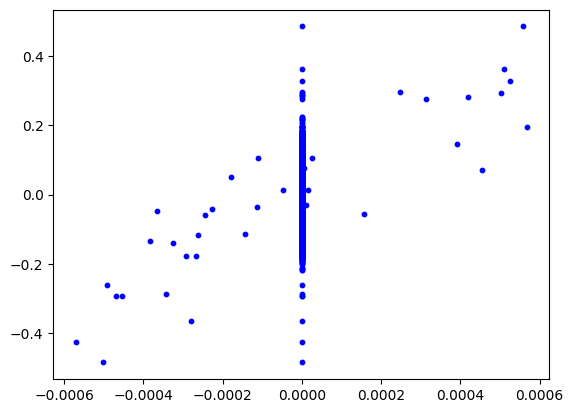

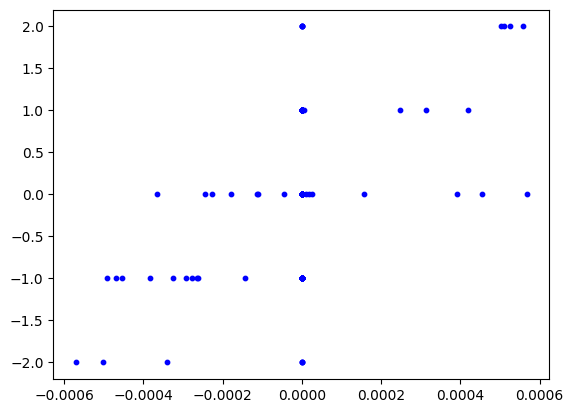

In [ ]:
## CHANGING RANDOM INTERACTIONS, FIXED ENVIRONMENTAL PREFS. Interaction changes are sign changes, but new magnitude (so could be large pos to small neg)
# for random matrix
interactFactor = 1/3
nSpec = 100
pInteract = 0.05
pPositive = 0.5

# parms for GLV sim
alpha = 0.001
samplesize = int(0.5 * nSpec) # number of species to sample
numtrials = 500
interactStren = alpha * interactFactor
b = np.ones(nSpec) #- np.random.uniform(low = 0, high = .1, size = (nSpec))

# Trait Matching Environment Noise
traits = np.random.uniform(low = 0, high = 1, size = (nSpec))

#Stage 1: Run in Environment=0
environ = 0

randMx_0 = metaCommunityMx.getRandomMatrix(maxInteractionStrength = interactStren, pPositive = pPositive, pInteract = pInteract, nSpecies = nSpec, pBidirectional = 0)

network_cooc_0, G_coocc_0, pearson_corr_0 = run_cooccurrence.get_coocc_network_traitmatch(interactionMx = randMx_0, cutoff =None, alpha = alpha, 
                                                                                          spsamplesize = samplesize, numtrials = numtrials, b = b, traits = traits, noise = 0.1, environ = environ)
print(environ)
#Stage 2: Change sign of desired number of interactions

extant = np.nonzero(randMx_0)

#Currently changes 10% of existing interactions

numchange = int(0.1*len(extant[0][:]))
print(numchange)
change_idx = np.random.choice(extant[0][:], size = numchange, replace = False)
print(change_idx)

randMx_1 = np.copy(randMx_0)

for i in change_idx:
    randMx_1[extant[0][i], extant[1][i]] = np.random.uniform(low = 0, high = interactStren)*-np.sign(randMx_1[extant[0][i], extant[1][i]])

#Stage 3: Run in Environment = 1 with flipped interactions

environ = 1
network_cooc_1, G_coocc_1, pearson_corr_1 = run_cooccurrence.get_coocc_network_traitmatch(interactionMx = randMx_1, cutoff =None, alpha = alpha, spsamplesize = samplesize, numtrials = numtrials, b = b, traits = traits, noise = 0.1, environ = environ)
print(environ)
#Stage 4: Calculate delta (interaction) and delta (coocc), plot

delta_interact = randMx_1 - randMx_0
delta_cooc = network_cooc_1 - network_cooc_0
delta_pears = pearson_corr_1 - pearson_corr_0

interact_flat = delta_interact.flatten()
cooc_flat = delta_cooc.flatten()
pears_flat = delta_pears.flatten()

plt.scatter(interact_flat, pears_flat, c = 'blue', s =10)
plt.show()
plt.scatter(interact_flat, cooc_flat, c = 'blue', s =10)

plt.show()


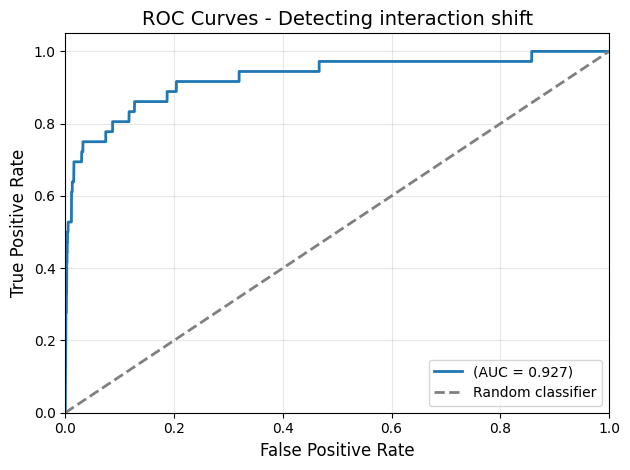

In [246]:
#Stage 5 - ROC curve for above data -- can it classify as changed(1)/unchanged(0) - currently from pearson vals
#Prepare data for ROC curve
binary_delta_interact = (delta_interact != 0).astype(int)
cooc_abs_test = np.abs(delta_cooc)
pears_abs_test = np.abs(delta_pears)

#Remove diagonal and flatten
mask = ~np.eye(binary_delta_interact.shape[0], dtype=bool)
binary_delta_interact_flat = binary_delta_interact[mask]
cooc_abs_test_flat = cooc_abs_test[mask]
pears_abs_test_flat = pears_abs_test[mask]

# Calculate ROC curve
fpr, tpr, thresholds = metrics.roc_curve(binary_delta_interact_flat, pears_abs_test_flat)
roc_auc = metrics.auc(fpr, tpr)

# Plot ROC curve
plt.plot(fpr, tpr, lw=2, 
        label=f'(AUC = {roc_auc:.3f})')

#Plot random classifier line
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Detecting interaction shift', fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



[ 0  1  3  4  6 10 12 13 18 20 21 23 24 27 28 29 30 31 33 35 39 41 42 44
 45 47 48 49 51 53 55 56 58 59 61 63 66 67 71 75 76 77 78 81 86 95 96 97]
[ 2  5  7  8  9 11 14 15 16 17 19 22 25 26 32 34 36 37 38 40 43 46 50 52
 54 57 60 62 64 65 68 69 70 72 73 74 79 80 82 83 84 85 87 88 89 90 91 92
 93 94 98 99]


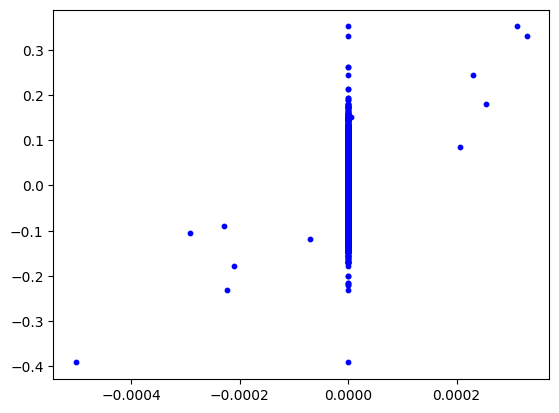

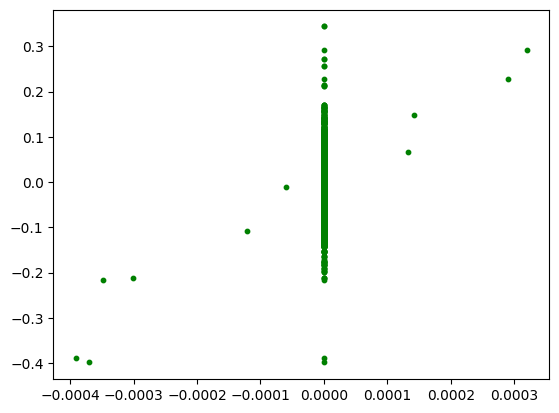

In [247]:
#Stage 6 - Parsing this out by shared vs non shared environmental preferences
pref_0 = np.where(traits < 0.5)[0]
print(pref_0[:])
pref_1 = np.where(traits > 0.5)[0]
print(pref_1[:])

group0_interact = delta_interact[np.ix_(pref_0[:], pref_0[:])]
group0_pears = delta_pears[np.ix_(pref_0[:], pref_0[:])]

group1_interact = delta_interact[np.ix_(pref_1[:], pref_1[:])]
group1_pears = delta_pears[np.ix_(pref_1[:], pref_1[:])]

crossgroup_a = delta_interact[np.ix_(pref_0[:], pref_1[:])]
crossgroup_b = delta_interact[np.ix_(pref_1[:], pref_0[:])]
crossgroup_a_pears = delta_pears[np.ix_(pref_0[:], pref_1[:])]
crossgroup_b_pears = delta_pears[np.ix_(pref_1[:], pref_0[:])]

group0interact_flat = group0_interact.flatten()
group0pears_flat = group0_pears.flatten()

group1interact_flat = group1_interact.flatten()
group1pears_flat = group1_pears.flatten()

crossgroup_a_flat = crossgroup_a.flatten()
crossgroup_apears_flat = crossgroup_a_pears.flatten()

crossgroup_b_flat = crossgroup_b.flatten()
crossgroup_bpears_flat = crossgroup_b_pears.flatten()

plt.scatter(group0interact_flat, group0pears_flat, c = 'blue', s =10)
plt.show()

plt.scatter(group1interact_flat, group1pears_flat, c = 'green', s =10)



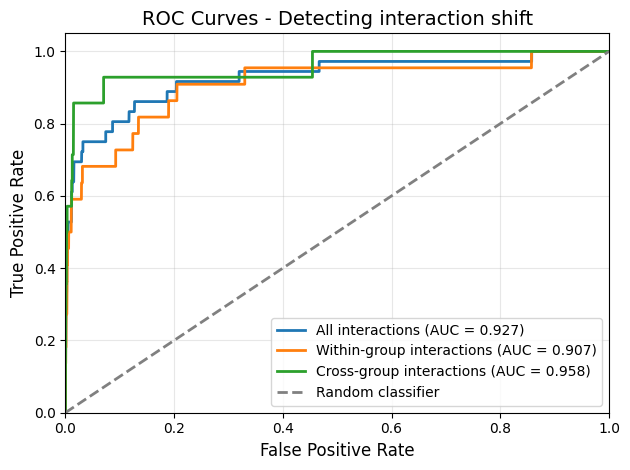

In [248]:
#Stage 7 - ROC curves with additional in vs out group interactions
#Prepare data for ROC curve
binary_delta_interact = (delta_interact != 0).astype(int)
pears_abs_test = np.abs(delta_pears)

binary_group0_interact = (group0_interact != 0).astype(int)
pears0_abs_test = np.abs(group0_pears)

binary_group1_interact = (group1_interact != 0).astype(int)
pears1_abs_test = np.abs(group1_pears)

#Remove diagonal and flatten (req for within-env-pref interactions)
mask_all = ~np.eye(binary_delta_interact.shape[0], dtype=bool)
binary_delta_interact_flat = binary_delta_interact[mask_all]
pears_abs_test_flat = pears_abs_test[mask_all]

mask0 = ~np.eye(binary_group0_interact.shape[0], dtype=bool)
binary_group0_interact_flat = binary_group0_interact[mask0]
pears0_abs_test_flat = pears0_abs_test[mask0]

mask1 = ~np.eye(binary_group1_interact.shape[0], dtype=bool)
binary_group1_interact_flat = binary_group1_interact[mask1]
pears1_abs_test_flat = pears1_abs_test[mask1]

binary_withingroup_interact = np.concatenate((binary_group0_interact_flat, binary_group1_interact_flat))
pears_withingroup_abs_test = np.concatenate((pears0_abs_test_flat, pears1_abs_test_flat))

#For crossgroups, concatenate flattened arrays
binary_crossgroupa_interact = (crossgroup_a_flat != 0).astype(int)
binary_crossgroupb_interact = (crossgroup_b_flat != 0).astype(int)

binary_crossgroup_interact = np.concatenate((binary_crossgroupa_interact, binary_crossgroupb_interact))

pearsa_abs_test = np.abs(crossgroup_apears_flat)
pearsb_abs_test = np.abs(crossgroup_bpears_flat)

pears_cross_abs_test = np.concatenate((pearsa_abs_test,pearsb_abs_test))

# Calculate ROC curve
fpr, tpr, thresholds = metrics.roc_curve(binary_delta_interact_flat, pears_abs_test_flat)
roc_auc = metrics.auc(fpr, tpr)

fprw, tprw, thresholdsw = metrics.roc_curve(binary_withingroup_interact, pears_withingroup_abs_test)
roc_aucw = metrics.auc(fprw, tprw)

fprc, tprc, thresholds0c= metrics.roc_curve(binary_crossgroup_interact, pears_cross_abs_test)
roc_auc_c = metrics.auc(fprc, tprc)

# Plot ROC curve
plt.plot(fpr, tpr, lw=2, label=f'All interactions (AUC = {roc_auc:.3f})')
plt.plot(fprw, tprw, lw=2, label=f'Within-group interactions (AUC = {roc_aucw:.3f})')
plt.plot(fprc, tprc, lw=2, label=f'Cross-group interactions (AUC = {roc_auc_c:.3f})')

#Plot random classifier line
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Detecting interaction shift', fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


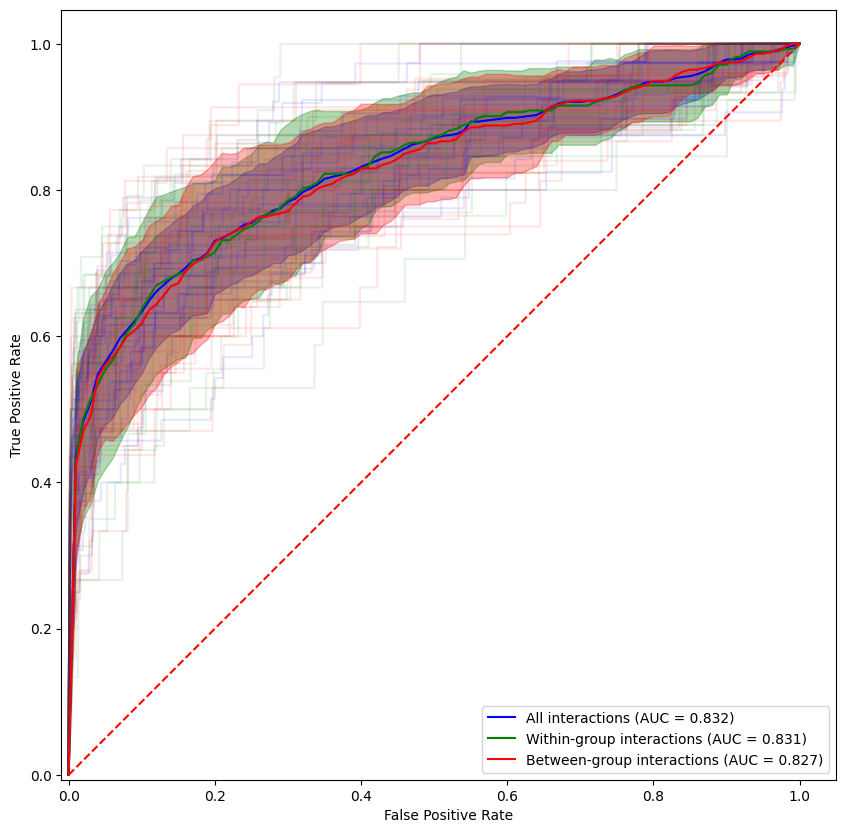

In [264]:
#Stage 8 - Code to run the above one-off simulation n times to generate a mean and confidence interval. 

interactFactor = 1/3
nSpec = 100
pInteract = 0.05
pPositive = 0.5

# parms for GLV sim
alpha = 0.001
samplesize = int(0.5 * nSpec) # number of species to sample
numtrials = 500
interactStren = alpha * interactFactor

#setup for plotting ROCs at the end
tprs = []
tprws = []
tprcs = []
roc_a = []
rocw = []
roc_c = []
base_fpr = np.linspace(0, 1, 101)

plt.figure(figsize=(10, 10))
plt.axes().set_aspect('equal', 'datalim')



for k in range(20):
    print(k)
    b = np.ones(nSpec) - np.random.uniform(low = 0, high = .1, size = (nSpec))

    #Trait Matching Environment Noise
    traits = np.random.uniform(low = 0, high = 1, size = (nSpec))

    #Run in Environment=0
    environ = 0

    randMx_0 = metaCommunityMx.getRandomMatrix(maxInteractionStrength = interactStren, pPositive = pPositive, pInteract = pInteract, nSpecies = nSpec, pBidirectional = 0)

    network_cooc_0, G_coocc_0, pearson_corr_0 = run_cooccurrence.get_coocc_network_traitmatch(interactionMx = randMx_0, cutoff =None, alpha = alpha, spsamplesize = samplesize, numtrials = numtrials, b = b, traits = traits, noise = 0.6, environ = environ)

    #Change sign of desired number of interactions (currently changing 10% of existing interactions)

    extant = np.nonzero(randMx_0)
    numchange = int(0.1*len(extant[0][:]))
    change_idx = np.random.choice(extant[0][:], size = numchange, replace = False)

    randMx_1 = np.copy(randMx_0)

    for i in change_idx:
        randMx_1[extant[0][i], extant[1][i]] = np.random.uniform(low = 0, high = interactStren)*-np.sign(randMx_1[extant[0][i], extant[1][i]])

    #Run in Environment = 1 with flipped interactions

    environ = 1
    network_cooc_1, G_coocc_1, pearson_corr_1 = run_cooccurrence.get_coocc_network_traitmatch(interactionMx = randMx_1, cutoff =None, alpha = alpha, spsamplesize = samplesize, numtrials = numtrials, b = b, traits = traits, noise = 0.6, environ = environ)

    #Calculate delta (interaction) and delta (coocc)
    delta_interact = randMx_1 - randMx_0
    delta_cooc = network_cooc_1 - network_cooc_0
    delta_pears = pearson_corr_1 - pearson_corr_0

    #Parse out within and between group interactions
    pref_0 = np.where(traits < 0.5)[0]
    pref_1 = np.where(traits > 0.5)[0]

    group0_interact = delta_interact[np.ix_(pref_0[:], pref_0[:])]
    group0_pears = delta_pears[np.ix_(pref_0[:], pref_0[:])]

    group1_interact = delta_interact[np.ix_(pref_1[:], pref_1[:])]
    group1_pears = delta_pears[np.ix_(pref_1[:], pref_1[:])]

    crossgroup_a = delta_interact[np.ix_(pref_0[:], pref_1[:])]
    crossgroup_b = delta_interact[np.ix_(pref_1[:], pref_0[:])]
    crossgroup_a_pears = delta_pears[np.ix_(pref_0[:], pref_1[:])]
    crossgroup_b_pears = delta_pears[np.ix_(pref_1[:], pref_0[:])]

    crossgroup_a_flat = crossgroup_a.flatten()
    crossgroup_apears_flat = crossgroup_a_pears.flatten()

    crossgroup_b_flat = crossgroup_b.flatten()
    crossgroup_bpears_flat = crossgroup_b_pears.flatten()

    #Prepare data for ROC curve

    binary_delta_interact = (delta_interact != 0).astype(int)
    pears_abs_test = np.abs(delta_pears)

    binary_group0_interact = (group0_interact != 0).astype(int)
    pears0_abs_test = np.abs(group0_pears)

    binary_group1_interact = (group1_interact != 0).astype(int)
    pears1_abs_test = np.abs(group1_pears)

    #Remove diagonal and flatten (req for within-env-pref interactions)

    mask_all = ~np.eye(binary_delta_interact.shape[0], dtype=bool)
    binary_delta_interact_flat = binary_delta_interact[mask_all]
    pears_abs_test_flat = pears_abs_test[mask_all]

    mask0 = ~np.eye(binary_group0_interact.shape[0], dtype=bool)
    binary_group0_interact_flat = binary_group0_interact[mask0]
    pears0_abs_test_flat = pears0_abs_test[mask0]

    mask1 = ~np.eye(binary_group1_interact.shape[0], dtype=bool)
    binary_group1_interact_flat = binary_group1_interact[mask1]
    pears1_abs_test_flat = pears1_abs_test[mask1]

    binary_withingroup_interact = np.concatenate((binary_group0_interact_flat, binary_group1_interact_flat))
    pears_withingroup_abs_test = np.concatenate((pears0_abs_test_flat, pears1_abs_test_flat))

    #For crossgroups, concatenate flattened arrays
    binary_crossgroupa_interact = (crossgroup_a_flat != 0).astype(int)
    binary_crossgroupb_interact = (crossgroup_b_flat != 0).astype(int)

    binary_crossgroup_interact = np.concatenate((binary_crossgroupa_interact, binary_crossgroupb_interact))

    pearsa_abs_test = np.abs(crossgroup_apears_flat)
    pearsb_abs_test = np.abs(crossgroup_bpears_flat)

    pears_cross_abs_test = np.concatenate((pearsa_abs_test,pearsb_abs_test))

    # Calculate ROC curve
    fpr, tpr, thresholds = metrics.roc_curve(binary_delta_interact_flat, pears_abs_test_flat)
    roc_auc = metrics.auc(fpr, tpr)

    fprw, tprw, thresholdsw = metrics.roc_curve(binary_withingroup_interact, pears_withingroup_abs_test)
    roc_aucw = metrics.auc(fprw, tprw)

    fprc, tprc, thresholds0c= metrics.roc_curve(binary_crossgroup_interact, pears_cross_abs_test)
    roc_auc_c = metrics.auc(fprc, tprc)

    plt.plot(fpr, tpr, 'b', alpha = 0.1)
    plt.plot(fprw, tprw, 'g', alpha = 0.1)
    plt.plot(fprc, tprc, 'r', alpha = 0.1)

    tpr = np.interp(base_fpr, fpr, tpr)
    tprw = np.interp(base_fpr, fprw, tprw)
    tprc = np.interp(base_fpr, fprc, tprc)
    tpr[0] = 0.0
    tprw[0] = 0.0
    tprc[0] = 0.0
    tprs.append(tpr)
    tprws.append(tprw)
    tprcs.append(tprc)

    roc_a.append(roc_auc)
    rocw.append(roc_aucw)
    roc_c.append(roc_auc_c)

#END LOOP HERE
tprs = np.array(tprs)
tprws = np.array(tprws)
tprcs = np.array(tprcs)

roc_a = np.array(roc_a)
rocw = np.array(rocw)
roc_c = np.array(roc_c)

mean_auc = roc_a.mean(axis=0)
mean_aucw = rocw.mean(axis=0)
mean_auc_c = roc_c.mean(axis=0)

mean_tprs = tprs.mean(axis=0)
std = tprs.std(axis=0)

mean_tprws = tprws.mean(axis=0)
stdw = tprws.std(axis=0)

mean_tprcs = tprcs.mean(axis=0)
stdc = tprcs.std(axis=0)

tprs_upper = np.minimum(mean_tprs + std, 1)
tprs_lower = mean_tprs - std

tprws_upper = np.minimum(mean_tprws + stdw, 1)
tprws_lower = mean_tprws - stdw

tprcs_upper = np.minimum(mean_tprcs + stdc, 1)
tprcs_lower = mean_tprcs - stdc


plt.plot(base_fpr, mean_tprs, 'b', label=f'All interactions (AUC = {mean_auc:.3f})')
plt.fill_between(base_fpr, tprs_lower, tprs_upper, color='blue', alpha=0.3)

plt.plot(base_fpr, mean_tprws, 'g', label=f'Within-group interactions (AUC = {mean_aucw:.3f})')
plt.fill_between(base_fpr, tprws_lower, tprws_upper, color='green', alpha=0.3)

plt.plot(base_fpr, mean_tprcs, 'r', label=f'Between-group interactions (AUC = {mean_auc_c:.3f})')
plt.fill_between(base_fpr, tprcs_lower, tprcs_upper, color='red', alpha=0.3)

plt.plot([0, 1], [0, 1],'r--')
plt.xlim([-0.01, 1.05])
plt.ylim([-0.01, 1.05])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend(loc="lower right", fontsize=10)
plt.show()

0
1
2
3
4
5
6
Did not reach equilibrium; run with higher tmax; System may not converge if interactions cause positive feedback loop.
5.0
7
8
9
10
11
12
13
Did not reach equilibrium; run with higher tmax; System may not converge if interactions cause positive feedback loop.
3.0
0.8349844393786655
0.8677078924451609
0.8891917988394848


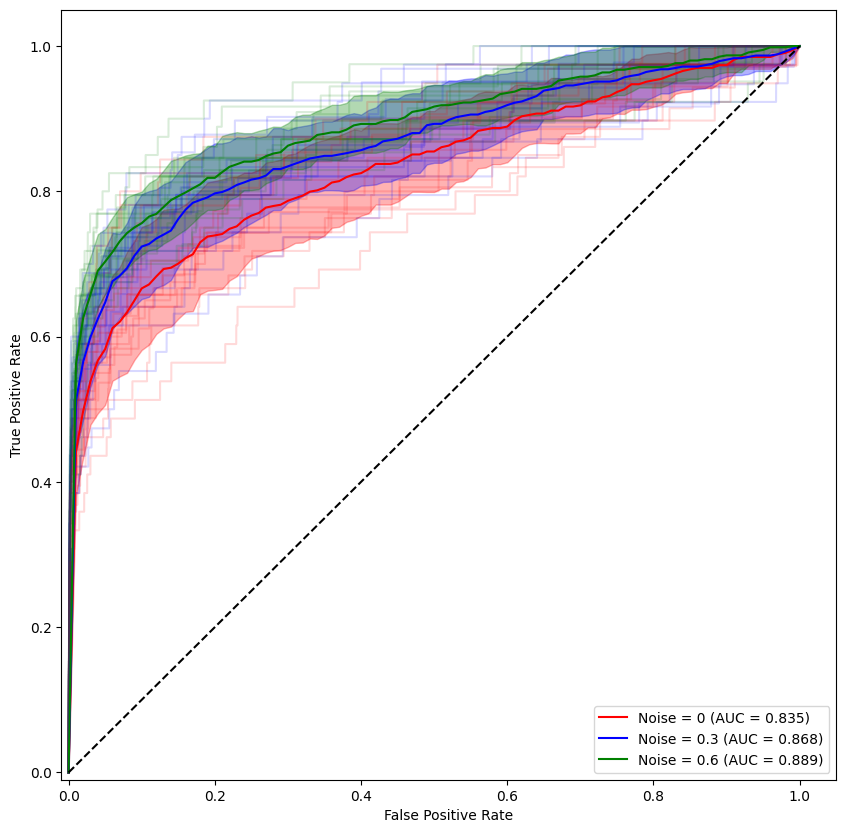

In [384]:
#Stage 9 -- running with different amounts of environmental noise (no longer separating within/between env pref groups)

interactFactor = 1/3
nSpec = 100
pInteract = 0.05
pPositive = 0.5

# parms for GLV sim
alpha = 0.001
samplesize = int(0.5 * nSpec) # number of species to sample
numtrials = 500
interactStren = alpha * interactFactor

#setup for plotting ROCs at the end
tpr_none = []
tpr_mid = []
tpr_max = []
base_fpr = np.linspace(0, 1, 101)

plt.figure(figsize=(10, 10))

noiselevels = np.array([0, 0.3, 0.6])
colors = ['red', 'blue','green'] 

auc = np.zeros(shape = (3,14))

for jj in range(4):
    print(jj)
    b = np.ones(nSpec) - np.random.uniform(low = 0, high = .1, size = (nSpec))
    traits = np.random.uniform(low = 0, high = 1, size = (nSpec))

    randMx_0 = metaCommunityMx.getRandomMatrix(maxInteractionStrength = interactStren, pPositive = pPositive, pInteract = pInteract, nSpecies = nSpec, pBidirectional = 0)
    #Change sign of desired number of interactions (currently changing 10% of existing interactions)

    extant = np.nonzero(randMx_0)
    numchange = int(0.1*len(extant[0][:]))
    change_idx = np.random.choice(extant[0][:], size = numchange, replace = False)

    randMx_1 = np.copy(randMx_0)
    for i in change_idx:
        randMx_1[extant[0][i], extant[1][i]] = np.random.uniform(low = 0, high = interactStren)*-np.sign(randMx_1[extant[0][i], extant[1][i]])

    for k in range(len(noiselevels)):
        
        noiselevel = noiselevels[k]

        #Run in Environment=0
        environ = 0
        network_cooc_0, G_coocc_0, pearson_corr_0 = run_cooccurrence.get_coocc_network_traitmatch(interactionMx = randMx_0, cutoff =None, alpha = alpha, spsamplesize = samplesize, numtrials = numtrials, b = b, traits = traits, noise = noiselevel, environ = environ)

        #Run in Environment = 1 with flipped interactions
        environ = 1
        network_cooc_1, G_coocc_1, pearson_corr_1 = run_cooccurrence.get_coocc_network_traitmatch(interactionMx = randMx_1, cutoff =None, alpha = alpha, spsamplesize = samplesize, numtrials = numtrials, b = b, traits = traits, noise = noiselevel, environ = environ)

        #Calculate delta (interaction) and delta (coocc)
        delta_interact = randMx_1 - randMx_0
        delta_cooc = network_cooc_1 - network_cooc_0
        delta_pears = pearson_corr_1 - pearson_corr_0

        #Prepare data for ROC curve

        binary_delta_interact = (delta_interact != 0).astype(int)
        pears_abs_test = np.abs(delta_pears)

        #Remove diagonal and flatten (req for within-env-pref interactions)

        mask_all = ~np.eye(binary_delta_interact.shape[0], dtype=bool)
        binary_delta_interact_flat = binary_delta_interact[mask_all]
        pears_abs_test_flat = pears_abs_test[mask_all]

        # Calculate ROC curve
        fpr, tpr, thresholds = metrics.roc_curve(binary_delta_interact_flat, pears_abs_test_flat)
        auc[k,jj] = metrics.auc(fpr, tpr)

        plt.plot(fpr, tpr, color = colors[k], alpha = 0.15)

        tpr = np.interp(base_fpr, fpr, tpr)
        tpr[0] = 0.0
        if k == 0:
            tpr_none.append(tpr)
        elif k == 1:
            tpr_mid.append(tpr)
        else: 
            tpr_max.append(tpr)
    

    
#END LOOP HERE

print(np.mean(auc[0]))
print(np.mean(auc[1]))
print(np.mean(auc[2]))

tpr_none = np.array(tpr_none)
tpr_mid = np.array(tpr_mid)
tpr_max = np.array(tpr_max)

mean_auc_none = np.mean(auc[0])
mean_auc_mid = np.mean(auc[1])
mean_auc_max = np.mean(auc[2])

mean_tpr_none = tpr_none.mean(axis=0)
std_none = tpr_none.std(axis=0)

mean_tpr_mid = tpr_mid.mean(axis=0)
std_mid = tpr_mid.std(axis=0)

mean_tpr_max = tpr_max.mean(axis=0)
std_max = tpr_max.std(axis=0)

tpr_n_upper = np.minimum(mean_tpr_none + std_none, 1)
tpr_n_lower = mean_tpr_none - std_none

tpr_mid_upper = np.minimum(mean_tpr_mid + std_mid, 1)
tpr_mid_lower = mean_tpr_mid - std_mid

tpr_max_upper = np.minimum(mean_tpr_max + std_max, 1)
tpr_max_lower = mean_tpr_max - std_max


plt.plot(base_fpr, mean_tpr_none, 'r', label=f'Noise = 0 (AUC = {mean_auc_none:.3f})')
plt.fill_between(base_fpr, tpr_n_lower, tpr_n_upper, color='red', alpha=0.3)

plt.plot(base_fpr, mean_tpr_mid, 'b', label=f'Noise = 0.3 (AUC = {mean_auc_mid:.3f})')
plt.fill_between(base_fpr, tpr_mid_lower, tpr_mid_upper, color='blue', alpha=0.3)

plt.plot(base_fpr, mean_tpr_max, 'g', label=f'Noise = 0.6 (AUC = {mean_auc_max:.3f})')
plt.fill_between(base_fpr, tpr_max_lower, tpr_max_upper, color='green', alpha=0.3)



plt.plot([0, 1], [0, 1],'k--')
plt.xlim([-0.01, 1.05])
plt.ylim([-0.01, 1.05])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend(loc="lower right", fontsize=10)
plt.show()


In [390]:
b = np.ones(nSpec)
mismatch = abs(traits-environ)
newb = b - .1*mismatch
print(np.mean(newb))
print(np.mean(b))


0.9513416059251525
1.0


0
50
[49 39 11 36 97 35 73 32 94 52 24 36 61 42 67 96 76 16 87 56  7 23 81 54
 81 85 89 85 96 54 70 75 74 37  5 35 70 99  8 29  7 31 33 68  9 47 63 84
 34 65]
1
[ 0  1  2  3  4  5  6  9 11 12 13 14 15 17 18 19 20 22 26 31 32 33 34 36
 40 42 45 46 49 51 52 53 54 55 57 59 61 63 64 65 66 67 70 71 73 79 80 82
 84 85 86 87 89 92 95 96 98]
[ 7  8 10 16 21 23 24 25 27 28 29 30 35 37 38 39 41 43 44 47 48 50 56 58
 60 62 68 69 72 74 75 76 77 78 81 83 88 90 91 93 94 97 99]
0.06153726664749221 657.1798803044529
0.05258566572786599 590.2919277033751


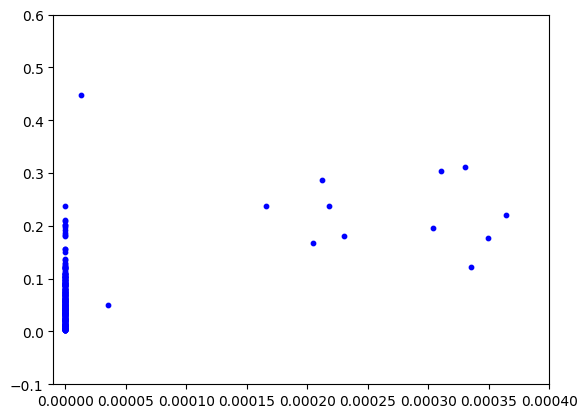

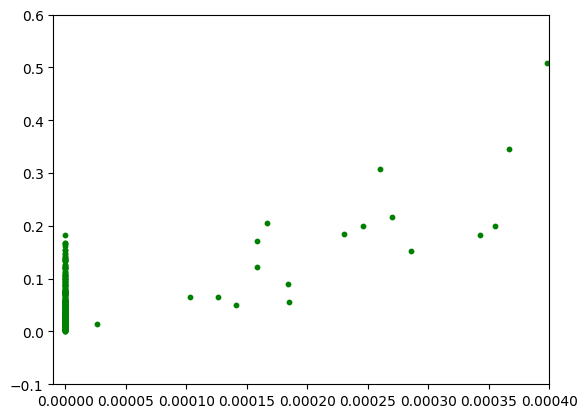

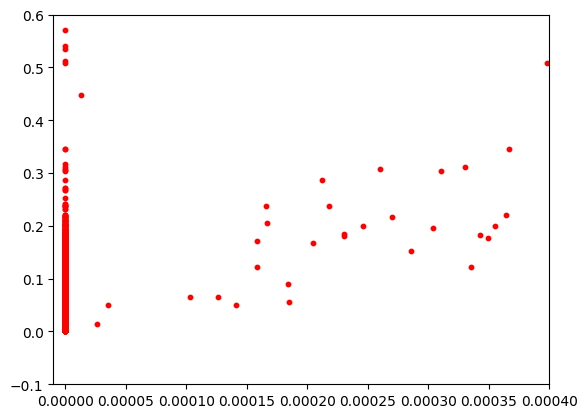

In [364]:
#Stage 10 -  Look at changes in coabundance signal vs type of interaction change
# for random matrix
interactFactor = 1/3
nSpec = 100
pInteract = 0.05
pPositive = 0.5

# parms for GLV sim
alpha = 0.001
samplesize = int(0.5 * nSpec) # number of species to sample
numtrials = 500
interactStren = alpha * interactFactor
b = np.ones(nSpec) - np.random.uniform(low = 0, high = .1, size = (nSpec))

# Trait Matching Environment Noise
traits = np.random.uniform(low = 0, high = 1, size = (nSpec))

#Stage 1: Run in Environment=0
environ = 0

randMx_0 = metaCommunityMx.getRandomMatrix(maxInteractionStrength = interactStren, pPositive = pPositive, pInteract = pInteract, nSpecies = nSpec, pBidirectional = 0)

network_cooc_0, G_coocc_0, pearson_corr_0 = run_cooccurrence.get_coocc_network_traitmatch(interactionMx = randMx_0, cutoff =None, alpha = alpha, spsamplesize = samplesize, numtrials = numtrials, b = b, traits = traits, noise = 0.3, environ = environ)
print(environ)
#Stage 2: Change sign of desired number of interactions

extant = np.nonzero(randMx_0)

#Currently changes 10% of existing interactions

numchange = int(0.1*len(extant[0][:]))
print(numchange)
change_idx = np.random.choice(extant[0][:], size = numchange, replace = False)
print(change_idx)

randMx_1 = np.copy(randMx_0)

for i in change_idx:
    randMx_1[extant[0][i], extant[1][i]] = np.random.uniform(low = 0, high = interactStren)*-np.sign(randMx_1[extant[0][i], extant[1][i]])

#Stage 3: Run in Environment = 1 with flipped interactions

environ = 1
network_cooc_1, G_coocc_1, pearson_corr_1 = run_cooccurrence.get_coocc_network_traitmatch(interactionMx = randMx_1, cutoff =None, alpha = alpha, spsamplesize = samplesize, numtrials = numtrials, b = b, traits = traits, noise = 0.3, environ = environ)
print(environ)
#Stage 4: Calculate delta (interaction) and delta (coocc), plot

delta_interact = randMx_1 - randMx_0
delta_cooc = network_cooc_1 - network_cooc_0
delta_pears = pearson_corr_1 - pearson_corr_0

pref_0 = np.where(traits < 0.5)[0]
pref_1 = np.where(traits > 0.5)[0]
print(pref_0)
print(pref_1)
sharedenv_interact = []
sharedenv_pears = []
sharedenv_cooc = []
diffenv_interact = []
diffenv_pears = []
diffenv_cooc =[]

for i in range(len(extant[0])):
    #check if shared env pref
    if ((extant[0][i] in pref_0) and (extant[1][i] in pref_0)):
        sharedenv_interact.append(delta_interact[extant[0][i], extant[1][i]])
        sharedenv_pears.append(delta_pears[extant[0][i], extant[1][i]])
        sharedenv_cooc.append(delta_cooc[extant[0][i], extant[1][i]])
    elif ((extant[0][i] in pref_1) and (extant[1][i] in pref_1)):
        sharedenv_interact.append(delta_interact[extant[0][i], extant[1][i]])
        sharedenv_pears.append(delta_pears[extant[0][i], extant[1][i]])
        sharedenv_cooc.append(delta_cooc[extant[0][i], extant[1][i]])
    #different env pref
    else:
        diffenv_interact.append(delta_interact[extant[0][i], extant[1][i]])
        diffenv_pears.append(delta_pears[extant[0][i], extant[1][i]])
        diffenv_cooc.append(delta_cooc[extant[0][i], extant[1][i]])

resultsame = stats.linregress(abs(np.array(sharedenv_interact)), abs(np.array(sharedenv_pears)))
print(resultsame.intercept, resultsame.slope)

resultdiff = stats.linregress(abs(np.array(diffenv_interact)),  abs(np.array(diffenv_pears)))
print(resultdiff.intercept, resultdiff.slope)


plt.scatter(abs(np.array(sharedenv_interact)), abs(np.array(sharedenv_pears)), c = 'blue', s=10)
plt.xlim([-0.00001, 0.0004])
plt.ylim([-0.1, 0.6])
plt.show()

plt.scatter(abs(np.array(diffenv_interact)), abs(np.array(diffenv_pears)), c = 'green',s=10)
plt.xlim([-0.00001, 0.0004])
plt.ylim([-0.1, 0.6])
plt.show()

plt.scatter(abs(delta_interact.flatten()), abs(delta_pears.flatten()), c='red',s=10)
plt.xlim([-0.00001, 0.0004])
plt.ylim([-0.1, 0.6])
plt.show()


In [376]:
a = np.zeros(shape = (2,3))
a[0,2]=3
b=np.mean(a[0])
print(b)

1.0


In [301]:
#Scratch testing
#randMx = metaCommunityMx.getRandomMatrix(maxInteractionStrength = interactStren, pPositive = pPositive, pInteract = pInteract, nSpecies = 30, pBidirectional = 0
print(len(extant[0]))
print(extant[1])
#Extant [0][i],[1][i] gives the individuals involved in the ith interaction change 
#randMx_0[extant[0][i],extant[1][i]] gives the original interaction between these two individuals; indexing randMx_1 will give the altered interaction
#Then can check if both individuals are in same list or not to see if there is a shared env preference, and add their abs(delta(interact) and abs(delta(pears)) to the appropriate list
#for the 90% of existing interactions *not* changed, also check if there is a shared env preference. delta(interact) will be 0 for these, and delta(pears) will be some amount
#of nonzero. These plots will be similar-ish to earlier ones, except now interact and didn't change will be clearly plotted independent of didn't interact and still don't
#Then plot each of the four scenarios (same/diff env and same/diff interaction) as own line
print(change_idx)
print(extant[0][21])
print(extant[1][21])
print(randMx_0[extant[0][21], extant[1][21]])
print(randMx_1[extant[0][21], extant[1][21]])
print(delta_interact[extant[0][21], extant[1][21]])
print(delta_pears[extant[0][21], extant[1][21]])



441
[ 9 42 51 74 22 46 59 76 84 98 13 17 52 61 10 11 18 24 50 61 64 72 86 96
  3 14 27 31 62 82  0  1  8 37 50 51 53 60 85 95  8 37 41 55 89 11 38 39
 56 61 79 86 93 58  3 43 60 91  0 17 24 45 41 52 88 31 74 90 97 98 19 52
 69 72 99 23 28 90 18 25 26 41 99  0 11 26 38 90 11 39 93 26 38 12 18 96
 15 30 36 60 76  9 11 26 29 81 84 94 97  0  4 32 45 58 88 99  7 42 90 18
 31 33 11 45 51 53 56  8 28 47 48 71 83 85 94 95 44 88 93 97  1  2 14 21
 33 36  5  7  8 64 76 89 53 78 85 86 92 99  1 55 60 10  9 19 23 64 71 57
 69 78 81 19 27 28 39 66 47 56 58 71 77 95  2 15 16 29 89  9 49 61 62 63
 81 83 86 92 99  4 33 59 61 77 50 72 83 88 98  5 39 43 52 79 83 87 59 90
 92 93 96 44 72 86  2 17 41 60 77 92 94  0  8 10 29 38 45 53 14 73 88  2
 15 21 25 28 71  7 15 19 32 88 89  6 10 27 44 81 25 91 12 18 26 29 38 40
 63 69 21 32 52 53 67 74 97  7 15 23 63 66 78 90 60 66 69 20 61 49 58 80
 98  2  5 28 33 58 65 84 98  2 14 81 90 13 34 49 40 75 97  5 14 16  3 21
 66 93  0  3  7 23 49 52 93 18 23 37 42 71 94 2